# Logistics Cost Analytics

## Project Overview

This project focuses on analyzing logistics and delivery operations to understand the key factors influencing transportation costs. Using data analysis, visualization, and machine learning techniques, the project identifies important cost drivers and develops a predictive model for estimating logistics costs. The insights generated from this analysis can support better planning, cost optimization, and operational decision-making in the logistics industry.

In [19]:
# Logistics Cost Analytics
# Data Loading and Initial Exploration

# Import required libraries
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("/content/Delivery_Logistics.csv")

# Display the first five records
df.head()

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600


## Introduction

Efficient logistics operations are essential for ensuring timely deliveries while controlling transportation costs. Analyzing delivery data helps identify the factors that influence logistics expenses, delivery performance, and operational efficiency.

This project explores a logistics delivery dataset using data analysis and machine learning techniques. The analysis focuses on understanding delivery patterns, identifying key cost drivers, and building a predictive model for estimating delivery costs. The insights obtained can support better planning and decision-making for logistics operations.

### Project Objectives

- Analyze the logistics dataset to understand delivery patterns and operational trends.
- Perform data cleaning and exploratory data analysis (EDA).
- Identify the major factors that influence delivery costs.
- Build and evaluate machine learning models for delivery cost prediction.
- Generate business insights and recommendations based on the analysis.

### Dataset Features

The dataset includes information related to:

- Delivery partners
- Package types
- Vehicle types
- Delivery modes
- Delivery regions
- Weather conditions
- Delivery distance
- Package weight
- Delivery time
- Expected delivery time
- Delivery status and ratings
- Delivery cost

### Expected Outcomes

By the end of this project, we aim to:

- Understand the key factors affecting logistics costs.
- Compare the impact of different delivery partners and transportation modes.
- Develop a machine learning model for delivery cost prediction.
- Provide data-driven recommendations to improve logistics operations.

## Importing Required Libraries

The following libraries are used throughout the project for data manipulation, visualization, and machine learning. These tools help in cleaning the dataset, exploring patterns, building predictive models, and evaluating their performance.

In [20]:
# ==========================================
# Import Required Libraries
# ==========================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

# Plot settings
plt.style.use("ggplot")
sns.set_palette("Set2")

## Data Loading and Understanding

In this section, the logistics dataset is loaded into the notebook and explored to understand its structure. We examine the dataset's dimensions, column names, data types, duplicate records, and basic statistics before proceeding with data cleaning and analysis.

In [21]:
# Data Loading and Understanding

# Display the first five records
print("First Five Records")
display(df.head())

# Display dataset information
print("\nDataset Information")
df.info()

# Display dataset shape
print("\nDataset Shape:", df.shape)

# Check missing values
print("\nMissing Values:")
display(df.isnull().sum())

# Check duplicate records
print("\nDuplicate Records:", df.duplicated().sum())

First Five Records


,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_id          25000 non-null  float64
 1   delivery_partner     25000 non-null  object 
 2   package_type         25000 non-null  object 
 3   vehicle_type         25000 non-null  object 
 4   delivery_mode        25000 non-null  object 
 5   region               25000 non-null  object 
 6   weather_condition    25000 non-null  object 
 7   distance_km          25000 non-null  float64
 8   package_weight_kg    25000 non-null  float64
 9   delivery_time_hours  25000 non-null  object 
 10  expected_time_hours  25000 non-null  object 
 11  delayed              25000 non-null  object 
 12  delivery_status      25000 non-null  object 
 13  delivery_rating      25000 non-null  int64  
 14  delivery_cost        25000 non-null  float64
dtypes: float64(4), 

,0
delivery_id,0
delivery_partner,0
package_type,0
vehicle_type,0
delivery_mode,0
region,0
weather_condition,0
distance_km,0
package_weight_kg,0
delivery_time_hours,0



Duplicate Records: 0


### Observations

- The dataset contains **25,000 records** and **15 features**.
- No missing values were found in the dataset.
- No duplicate records were detected.
- The dataset contains both numerical and categorical variables, making it suitable for further analysis and predictive modeling.

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is an important step in the data analysis process. It helps us understand the characteristics of the dataset by examining summary statistics, identifying patterns, detecting anomalies, and exploring relationships between different variables.

In this project, EDA is performed to gain insights into logistics operations, understand the factors affecting delivery costs, and prepare the data for predictive modeling.

In [22]:
# Exploratory Data Analysis

# Summary statistics for numerical features
print("=" * 60)
print("SUMMARY STATISTICS - NUMERICAL FEATURES")
print("=" * 60)
display(df.describe())

# Summary statistics for categorical features
print("\n" + "=" * 60)
print("SUMMARY STATISTICS - CATEGORICAL FEATURES")
print("=" * 60)
display(df.describe(include='object'))

SUMMARY STATISTICS - NUMERICAL FEATURES


,delivery_id,distance_km,package_weight_kg,delivery_rating,delivery_cost
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,12500.500000,150.390436,25.145898,3.666000,864.944579
std,7212.732314,86.409745,14.368663,1.149964,435.712593
min,250.990000,3.600000,0.670000,1.000000,95.667400
25%,6250.750000,75.900000,12.680000,3.000000,490.800000
50%,12500.500000,151.000000,25.145000,4.000000,867.535000
75%,18750.250000,224.900000,37.660000,5.000000,1237.910000
max,24750.010000,297.100000,49.520000,5.000000,1632.720600



SUMMARY STATISTICS - CATEGORICAL FEATURES


,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,delivery_time_hours,expected_time_hours,delayed,delivery_status
count,25000,25000,25000,25000,25000,25000,25000,25000,25000,25000
unique,9,9,6,4,5,6,20,9,2,3
top,xpressbees,fragile items,ev bike,two day,west,foggy,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000016,no,delivered
freq,2826,2848,4218,6302,5095,4219,3118,6302,18331,18331


## Distribution of Numerical Variables

Understanding the distribution of numerical variables helps identify their spread, central tendency, and potential outliers. This analysis provides insights into important logistics features such as delivery distance, package weight, delivery rating, and delivery cost.

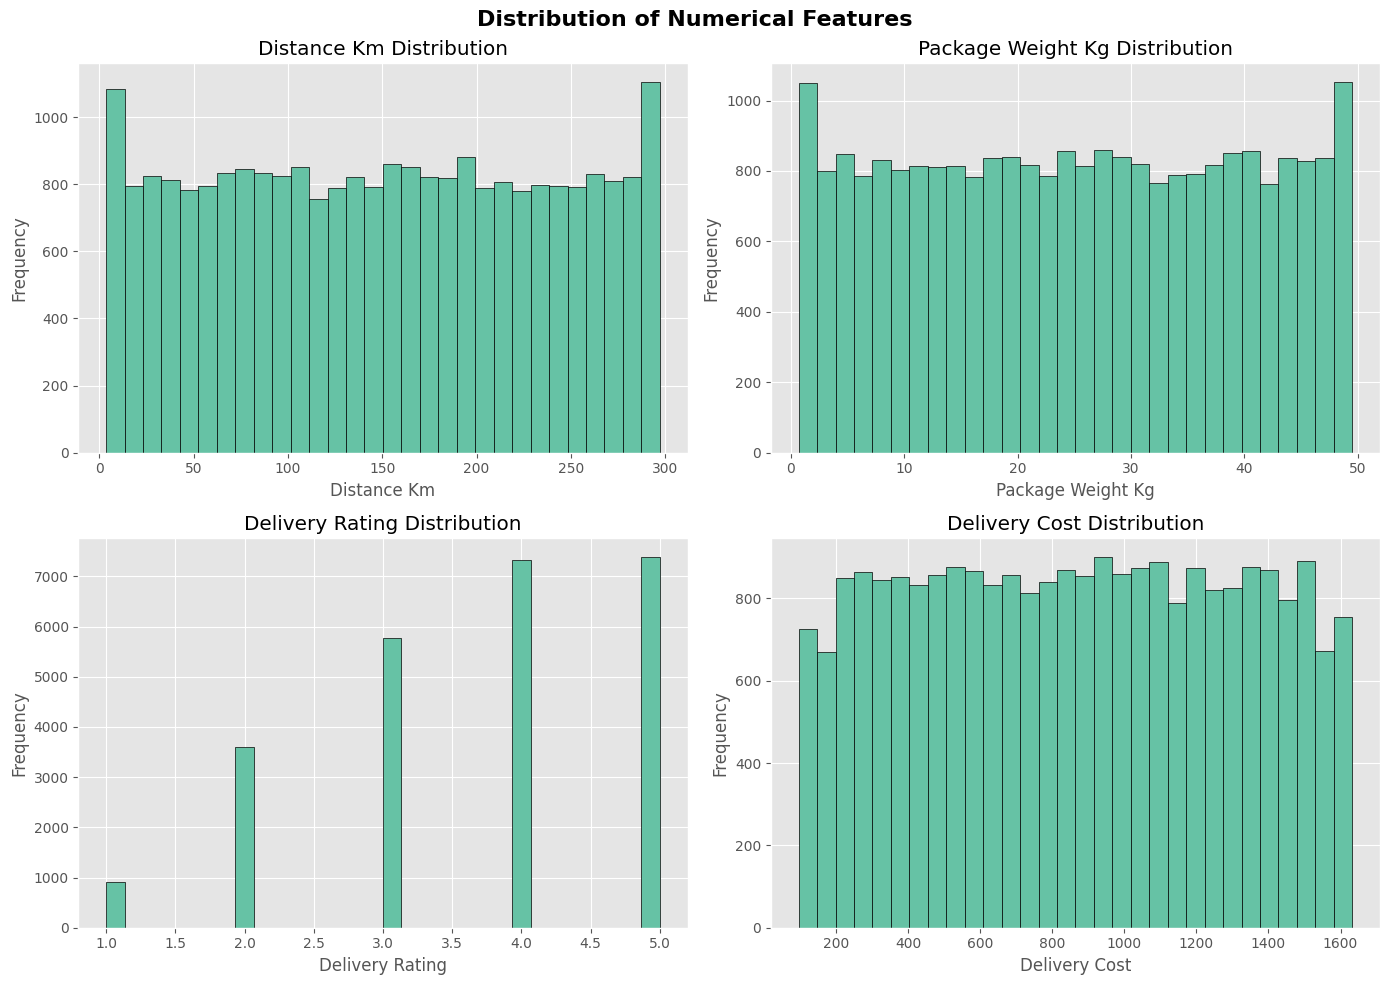

In [23]:
# Distribution of Numerical Variables

# Numerical columns for analysis
numerical_cols = [
    'distance_km',
    'package_weight_kg',
    'delivery_rating',
    'delivery_cost'
]

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Plot histograms
for i, column in enumerate(numerical_cols):
    axes[i].hist(df[column], bins=30, edgecolor='black')
    axes[i].set_title(f'{column.replace("_", " ").title()} Distribution')
    axes[i].set_xlabel(column.replace("_", " ").title())
    axes[i].set_ylabel('Frequency')

plt.suptitle("Distribution of Numerical Features", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Distribution of Categorical Variables

Categorical variables represent different characteristics of logistics operations, such as delivery partners, vehicle types, delivery modes, regions, and weather conditions. Analyzing their distributions helps understand the composition of the dataset and identify the most common operational categories.

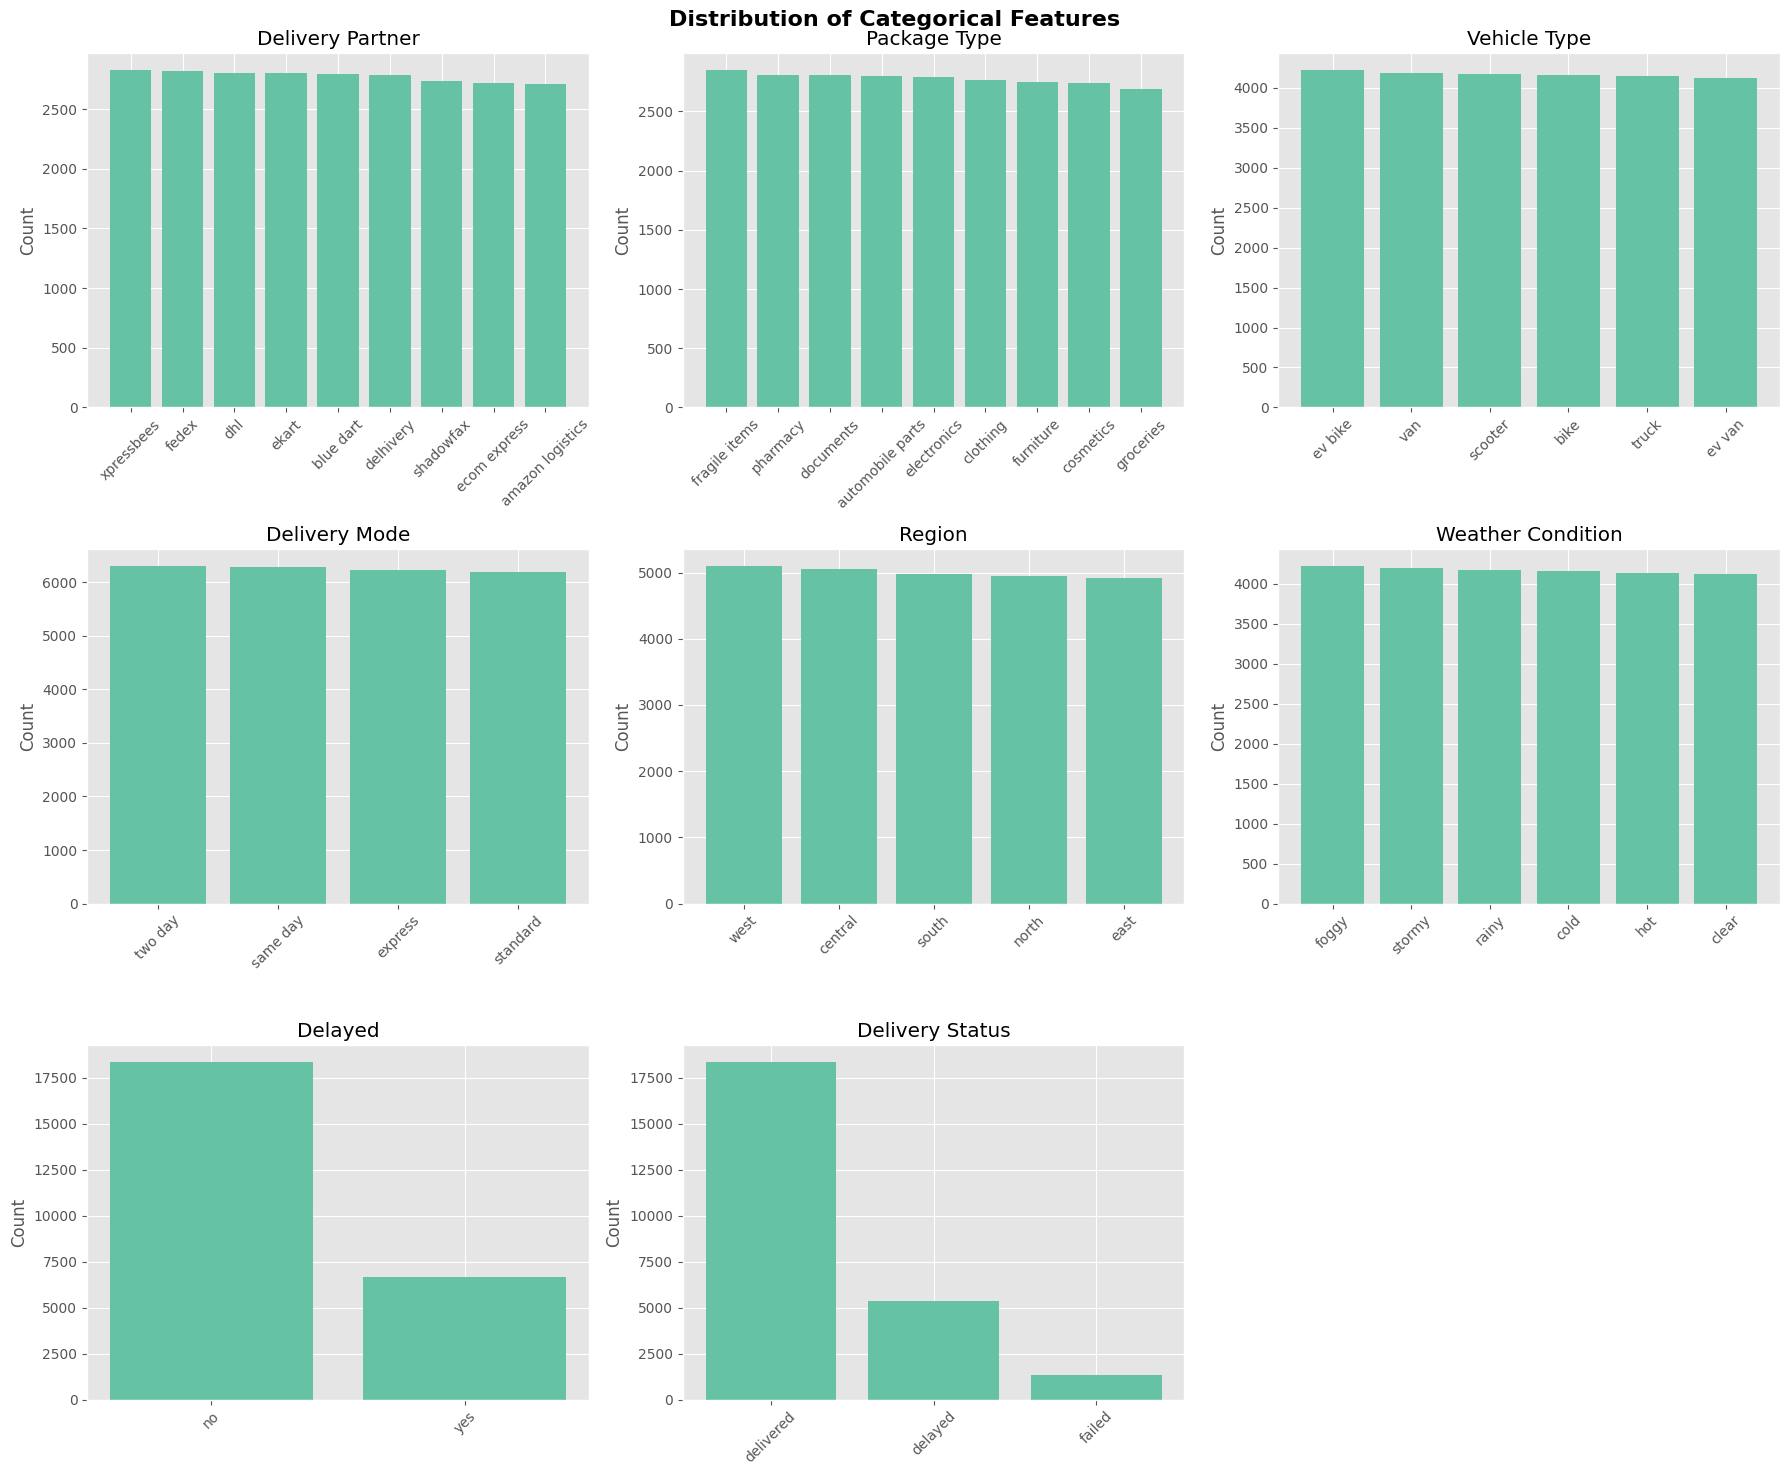

In [24]:
# Distribution of Categorical Variables

# List of categorical columns
categorical_cols = [
    'delivery_partner',
    'package_type',
    'vehicle_type',
    'delivery_mode',
    'region',
    'weather_condition',
    'delayed',
    'delivery_status'
]

# Create subplots
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

# Plot bar charts for each categorical feature
for i, column in enumerate(categorical_cols):

    # Get category counts
    value_counts = df[column].value_counts()

    # Display only the top 10 categories if there are many
    if len(value_counts) > 10:
        value_counts = value_counts.head(10)

    axes[i].bar(value_counts.index, value_counts.values)

    axes[i].set_title(column.replace("_", " ").title())
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

# Hide unused subplot
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribution of Categorical Features", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Correlation Analysis

Correlation analysis helps measure the strength and direction of relationships between numerical variables. It allows us to identify which features are closely associated with delivery cost and other important logistics metrics. Understanding these relationships is useful for feature selection and predictive modeling.

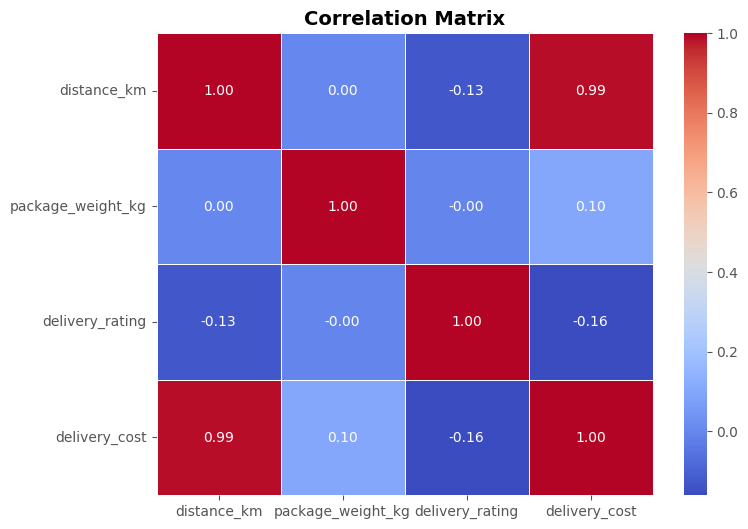

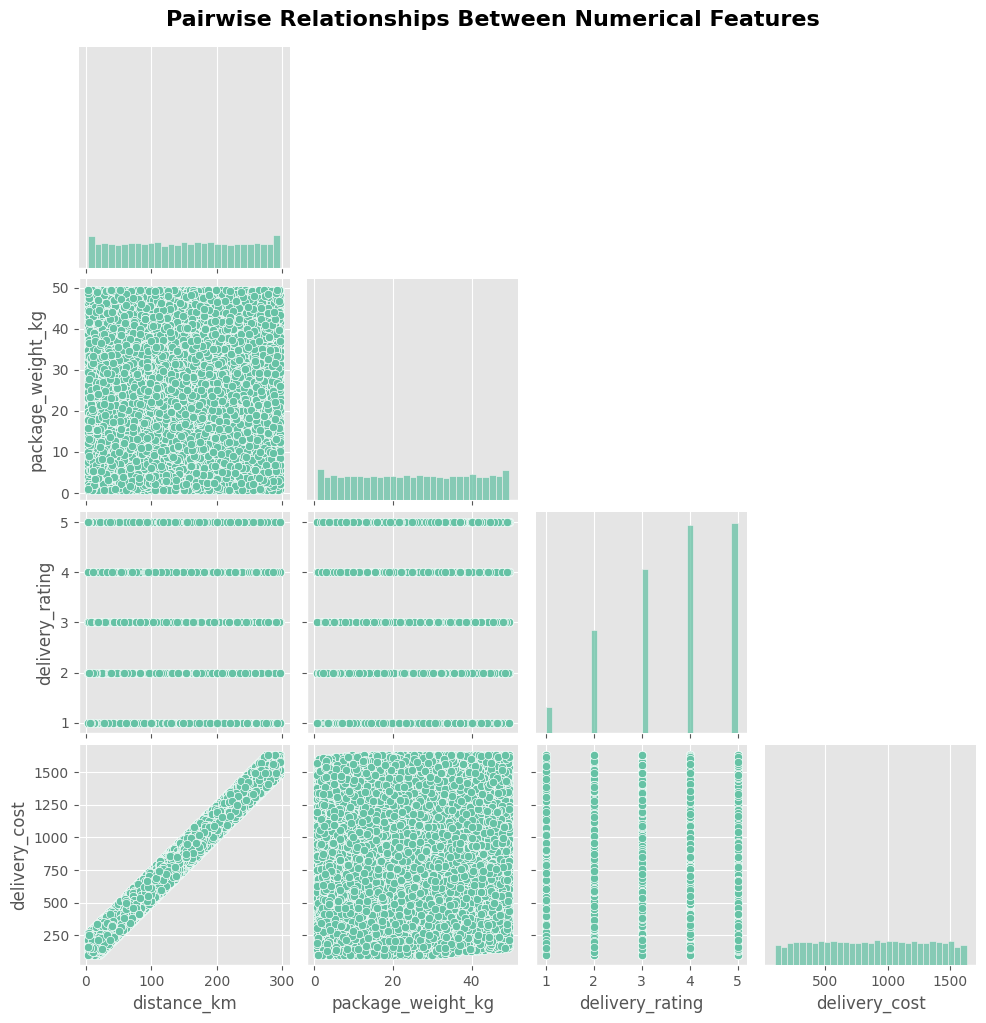

In [25]:
# Correlation Analysis

# Select numerical columns
numerical_cols = [
    'distance_km',
    'package_weight_kg',
    'delivery_rating',
    'delivery_cost'
]

# Calculate correlation matrix
corr_matrix = df[numerical_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Matrix", fontsize=14, fontweight='bold')
plt.show()


# Pairwise Relationship Analysis

sns.pairplot(
    df[numerical_cols],
    diag_kind='hist',
    corner=True
)

plt.suptitle("Pairwise Relationships Between Numerical Features",
             fontsize=16,
             fontweight='bold',
             y=1.02)

plt.show()

## Numerical vs Categorical Analysis

This analysis examines how numerical variables vary across different categorical features. Box plots help visualize the distribution of values, identify variations between categories, and detect potential outliers. These insights are useful for understanding the factors that influence logistics operations and delivery costs.

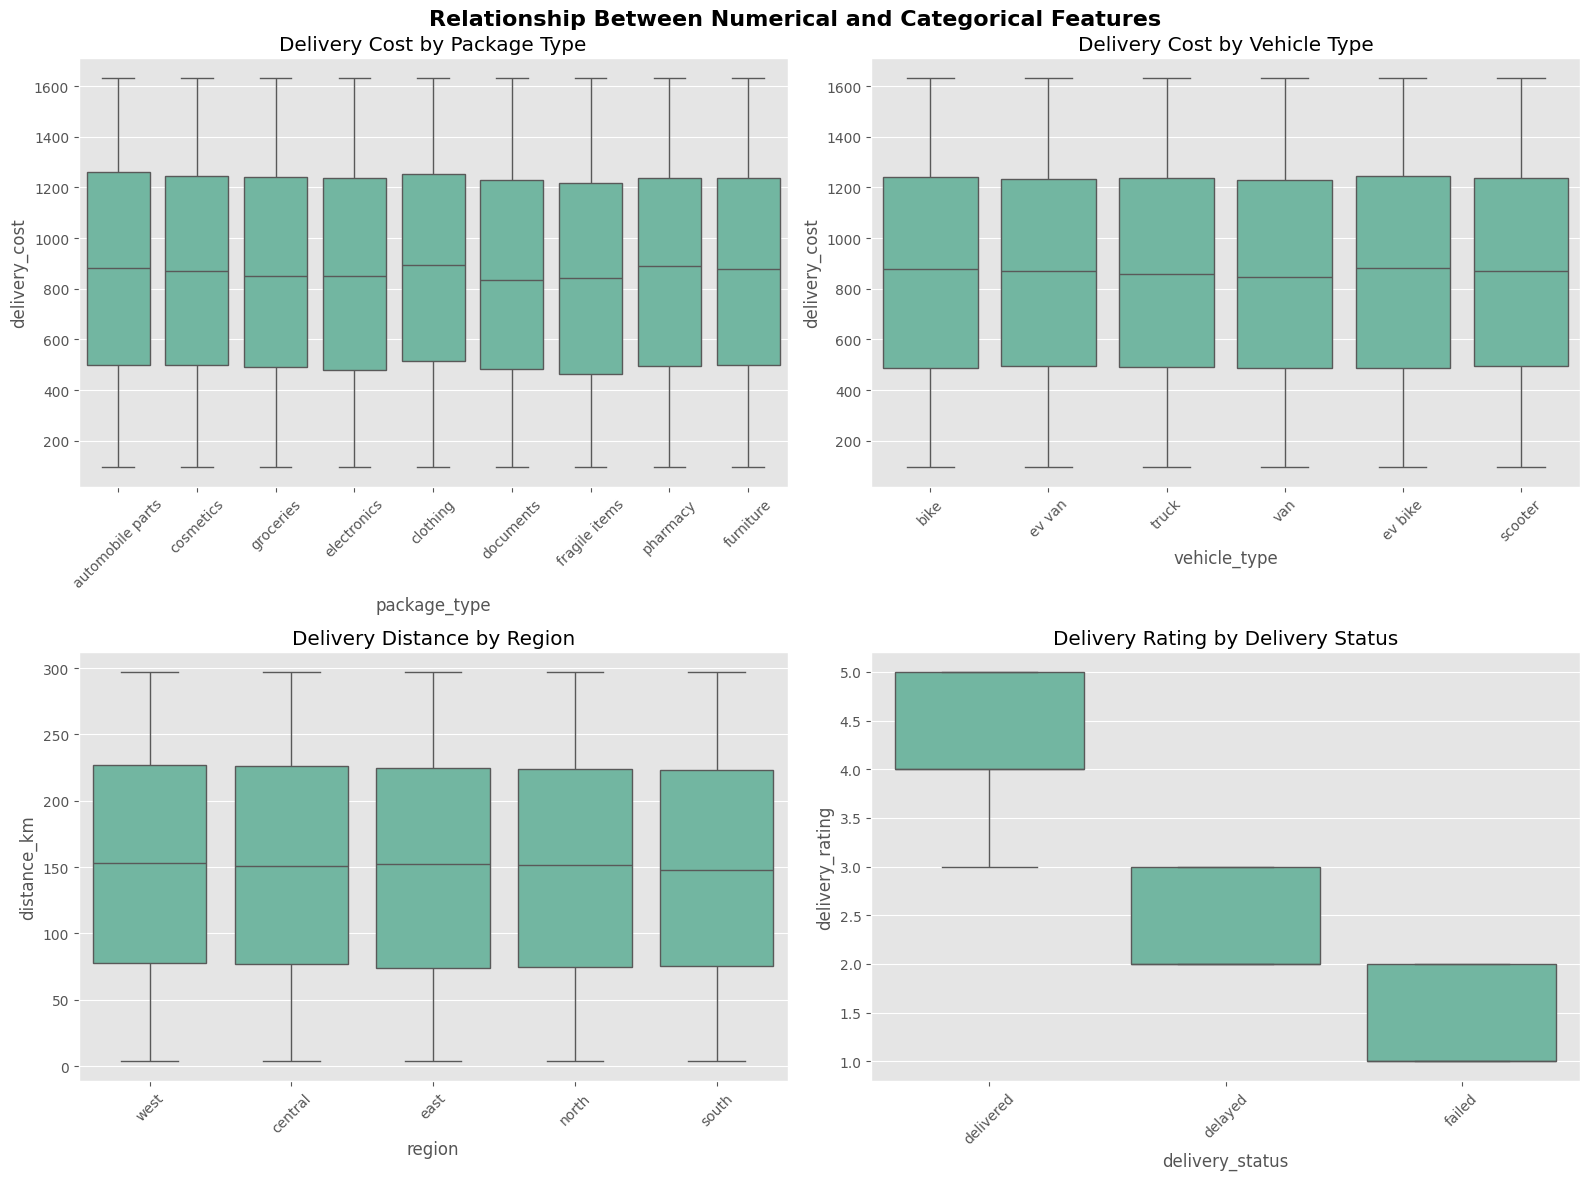

In [26]:
# Numerical vs Categorical Analysis

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Delivery Cost by Package Type
sns.boxplot(data=df, x='package_type', y='delivery_cost', ax=axes[0, 0])
axes[0, 0].set_title('Delivery Cost by Package Type')
axes[0, 0].tick_params(axis='x', rotation=45)

# Delivery Cost by Vehicle Type
sns.boxplot(data=df, x='vehicle_type', y='delivery_cost', ax=axes[0, 1])
axes[0, 1].set_title('Delivery Cost by Vehicle Type')
axes[0, 1].tick_params(axis='x', rotation=45)

# Delivery Distance by Region
sns.boxplot(data=df, x='region', y='distance_km', ax=axes[1, 0])
axes[1, 0].set_title('Delivery Distance by Region')
axes[1, 0].tick_params(axis='x', rotation=45)

# Delivery Rating by Delivery Status
sns.boxplot(data=df, x='delivery_status', y='delivery_rating', ax=axes[1, 1])
axes[1, 1].set_title('Delivery Rating by Delivery Status')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle("Relationship Between Numerical and Categorical Features",
             fontsize=16,
             fontweight='bold')

plt.tight_layout()
plt.show()

## Delivery Performance Analysis

This section evaluates key delivery performance metrics, including delivery status, delays, customer ratings, and the impact of weather conditions. Understanding these factors helps assess operational efficiency and identify areas for improving logistics performance.

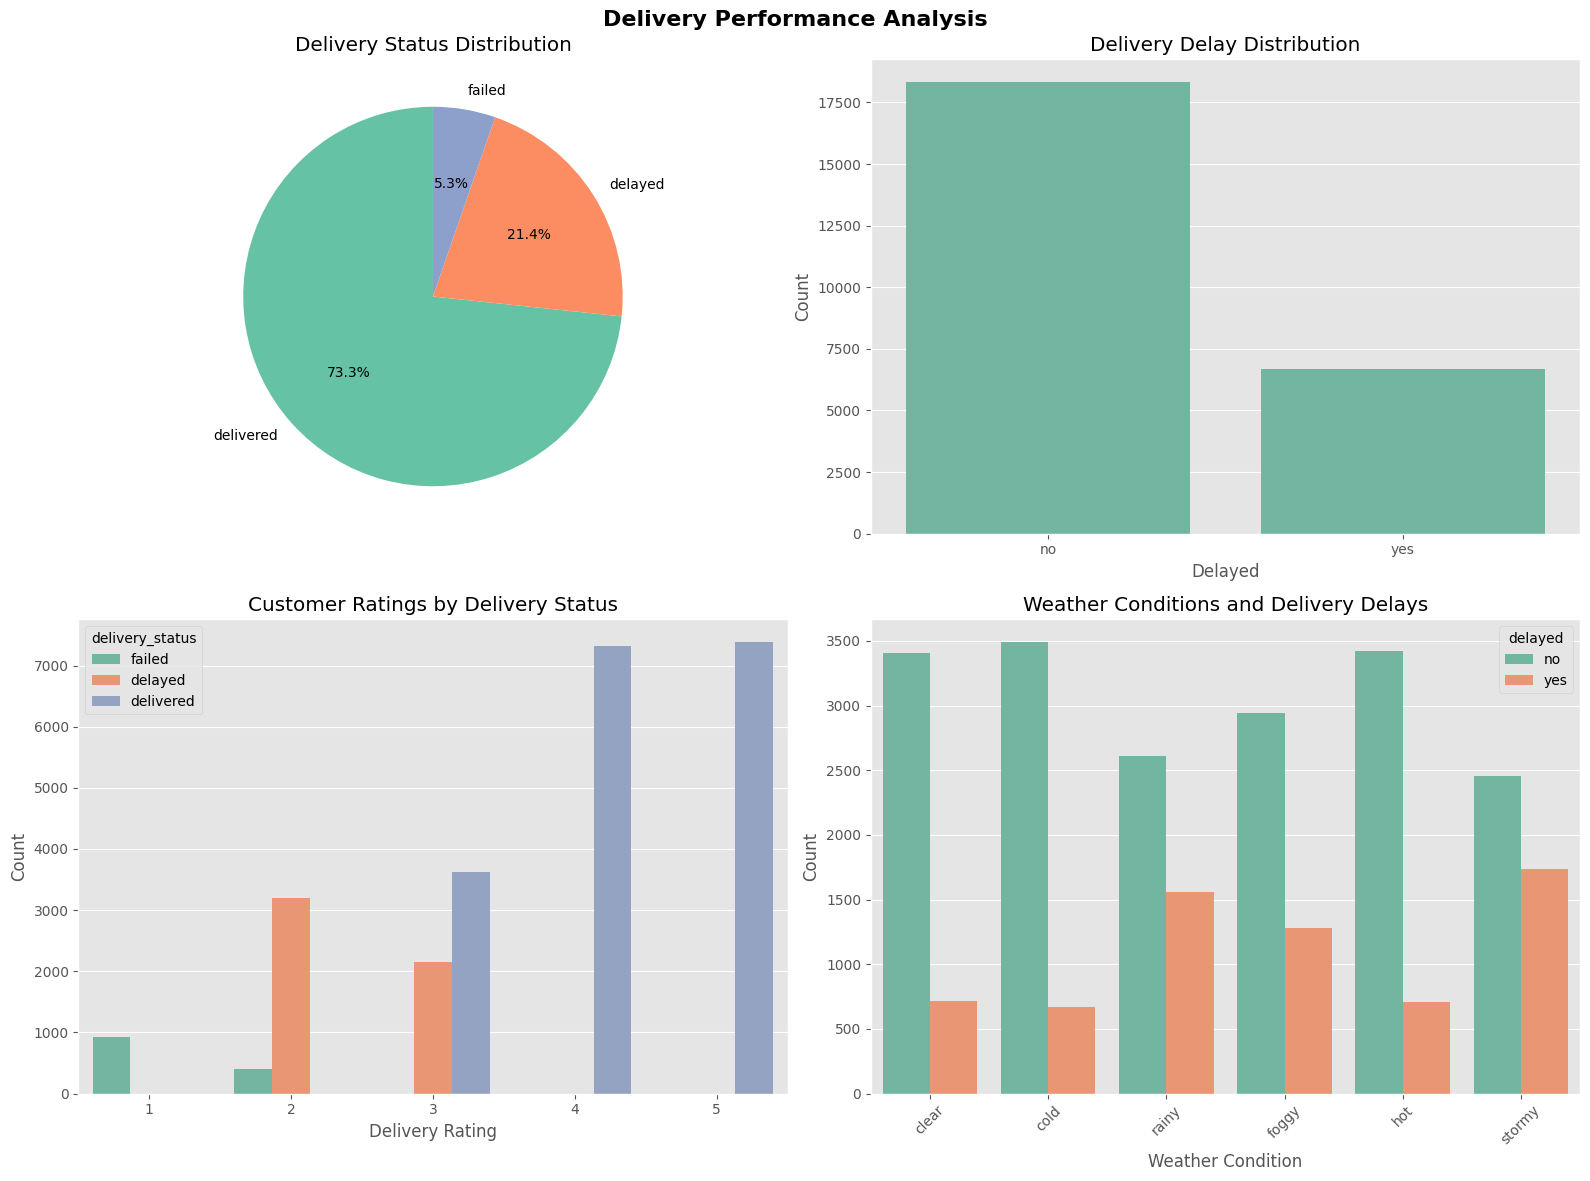

In [27]:
# Delivery Performance Analysis

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Delivery Status Distribution
status_counts = df['delivery_status'].value_counts()

axes[0, 0].pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
axes[0, 0].set_title("Delivery Status Distribution")


# 2. Delivery Delay Distribution
sns.countplot(data=df, x='delayed', ax=axes[0, 1])
axes[0, 1].set_title("Delivery Delay Distribution")
axes[0, 1].set_xlabel("Delayed")
axes[0, 1].set_ylabel("Count")


# 3. Customer Rating by Delivery Status
sns.countplot(
    data=df,
    x='delivery_rating',
    hue='delivery_status',
    ax=axes[1, 0]
)

axes[1, 0].set_title("Customer Ratings by Delivery Status")
axes[1, 0].set_xlabel("Delivery Rating")
axes[1, 0].set_ylabel("Count")


# 4. Weather Conditions vs Delivery Delays
sns.countplot(
    data=df,
    x='weather_condition',
    hue='delayed',
    ax=axes[1, 1]
)

axes[1, 1].set_title("Weather Conditions and Delivery Delays")
axes[1, 1].set_xlabel("Weather Condition")
axes[1, 1].set_ylabel("Count")
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle(
    "Delivery Performance Analysis",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Delivery Partner Performance Analysis

Delivery partners play an important role in logistics operations. This analysis compares delivery partners based on customer ratings and successful delivery rates to better understand their overall performance.

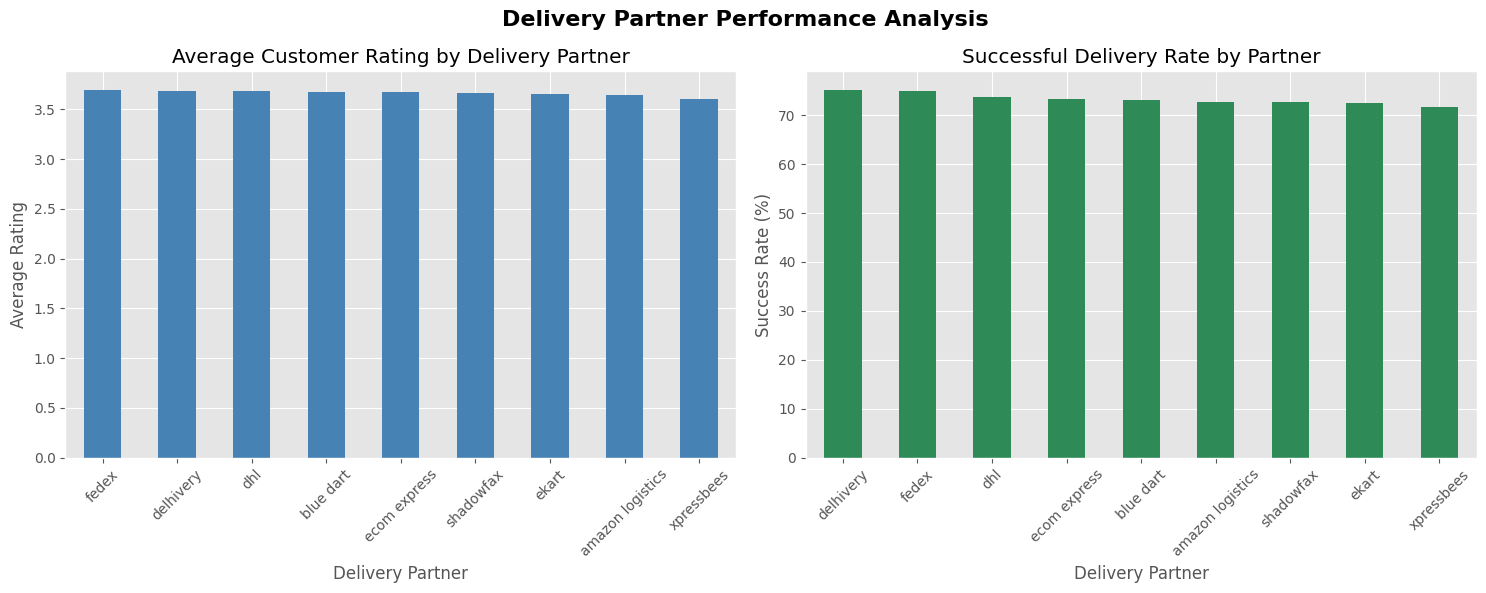

In [28]:
# Delivery Partner Performance Analysis

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Average customer rating by delivery partner
partner_rating = (
    df.groupby('delivery_partner')['delivery_rating']
      .mean()
      .sort_values(ascending=False)
)

partner_rating.plot(
    kind='bar',
    ax=axes[0],
    color='steelblue'
)

axes[0].set_title("Average Customer Rating by Delivery Partner")
axes[0].set_xlabel("Delivery Partner")
axes[0].set_ylabel("Average Rating")
axes[0].tick_params(axis='x', rotation=45)


# Successful delivery percentage
partner_success = (
    df.groupby('delivery_partner')['delivery_status']
      .apply(lambda x: (x.str.lower() == 'delivered').mean() * 100)
      .sort_values(ascending=False)
)

partner_success.plot(
    kind='bar',
    ax=axes[1],
    color='seagreen'
)

axes[1].set_title("Successful Delivery Rate by Partner")
axes[1].set_xlabel("Delivery Partner")
axes[1].set_ylabel("Success Rate (%)")
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle(
    "Delivery Partner Performance Analysis",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## Key Insights Summary

The following summary highlights the major findings from the exploratory data analysis. These insights provide a quick overview of delivery performance, customer satisfaction, logistics operations, and the factors influencing delivery costs.

In [29]:
# Key Insights Summary

print("=" * 60)
print("LOGISTICS DATASET - KEY INSIGHTS")
print("=" * 60)

# Delivery Success Rate
success_rate = (df['delivery_status'].str.lower() == 'delivered').mean() * 100
print(f"Successful Delivery Rate : {success_rate:.2f}%")

# Average Customer Rating
avg_rating = df['delivery_rating'].mean()
print(f"Average Customer Rating  : {avg_rating:.2f} / 5")

# Delivery Delay Rate
delay_rate = (df['delayed'].str.lower() == 'yes').mean() * 100
print(f"Delivery Delay Rate      : {delay_rate:.2f}%")

# Average Delivery Cost
avg_cost = df['delivery_cost'].mean()
print(f"Average Delivery Cost    : ₹{avg_cost:.2f}")

# Most Common Package Type
common_package = df['package_type'].mode()[0]
print(f"Most Common Package      : {common_package}")

# Most Used Vehicle Type
common_vehicle = df['vehicle_type'].mode()[0]
print(f"Most Used Vehicle        : {common_vehicle}")

# Average Delivery Distance
avg_distance = df['distance_km'].mean()
print(f"Average Distance         : {avg_distance:.2f} km")

# Correlation between Distance and Cost
corr = df['distance_km'].corr(df['delivery_cost'])
print(f"Distance-Cost Correlation: {corr:.2f}")

print("=" * 60)
print("EDA COMPLETED SUCCESSFULLY")
print("=" * 60)

LOGISTICS DATASET - KEY INSIGHTS
Successful Delivery Rate : 73.32%
Average Customer Rating  : 3.67 / 5
Delivery Delay Rate      : 26.68%
Average Delivery Cost    : ₹864.94
Most Common Package      : fragile items
Most Used Vehicle        : ev bike
Average Distance         : 150.39 km
Distance-Cost Correlation: 0.99
EDA COMPLETED SUCCESSFULLY


## Feature Engineering

Feature engineering is the process of creating or modifying features to improve the performance of machine learning models. In this project, a few meaningful features are created using simple transformations to better represent the logistics data while keeping the analysis easy to understand.

In [30]:
# ==========================================
# Feature Engineering
# ==========================================

# Create a copy of the dataset
df_processed = df.copy()

# ------------------------------------------
# Remove unnecessary columns
# ------------------------------------------

columns_to_drop = [
    'delivery_id',
    'delivery_time_hours',
    'expected_time_hours'
]

df_processed.drop(columns=columns_to_drop, inplace=True)

print("Removed unnecessary columns.")

# ------------------------------------------
# Create New Features
# ------------------------------------------

# Package Weight Category
df_processed['weight_category'] = pd.cut(
    df_processed['package_weight_kg'],
    bins=[0, 10, 25, 50],
    labels=['Light', 'Medium', 'Heavy']
)

# Long Distance Delivery
df_processed['long_distance'] = (
    df_processed['distance_km'] > 150
).astype(int)

# Heavy Package
df_processed['heavy_package'] = (
    df_processed['package_weight_kg'] > 25
).astype(int)

print("Created new features:")
print("- weight_category")
print("- long_distance")
print("- heavy_package")

# ------------------------------------------
# Encode Categorical Variables
# ------------------------------------------

label_encoder = LabelEncoder()

categorical_columns = df_processed.select_dtypes(
    include=['object', 'category']
).columns

for column in categorical_columns:
    df_processed[column] = label_encoder.fit_transform(
        df_processed[column].astype(str)
    )

print("Categorical variables encoded successfully.")

# ------------------------------------------
# Display Processed Dataset
# ------------------------------------------

print("\nProcessed Dataset Shape:", df_processed.shape)

display(df_processed.head())

Removed unnecessary columns.
Created new features:
- weight_category
- long_distance
- heavy_package
Categorical variables encoded successfully.

Processed Dataset Shape: (25000, 15)


,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,delivery_status,delivery_rating,delivery_cost,weight_category,long_distance,heavy_package
0,2,0,0,1,4,0,297.0,46.96,0,1,3,1632.7206,0,1,1
1,8,2,2,0,0,1,89.6,47.39,0,1,5,640.1700,0,0,1
2,7,7,4,3,1,4,273.5,26.89,0,1,4,1448.1700,0,1,1
3,3,4,2,1,1,1,269.7,12.69,0,1,3,1486.5700,2,1,0
4,3,1,5,3,2,2,256.7,37.02,0,1,4,1394.5600,0,1,1


## Data Preprocessing

Before building machine learning models, the dataset is prepared by removing unnecessary columns, encoding categorical variables, and separating the input features from the target variable. Proper preprocessing ensures that the data is suitable for model training and improves prediction performance.

MACHINE LEARNING MODEL DEVELOPMENT

Data prepared successfully.
Training Shape : (20000, 14)
Testing Shape  : (5000, 14)

Training Models...

✔ Linear Regression completed
✔ Decision Tree completed
✔ Random Forest completed

Model Performance


,Model,MAE,RMSE,Median Error
0,Random Forest,2.34,3.25,1.69
1,Decision Tree,9.49,11.91,8.13
2,Linear Regression,25.19,30.57,25.24


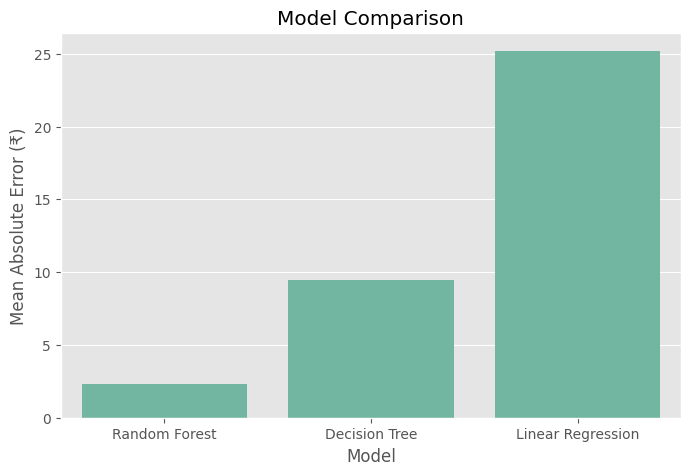


Best Model : Random Forest


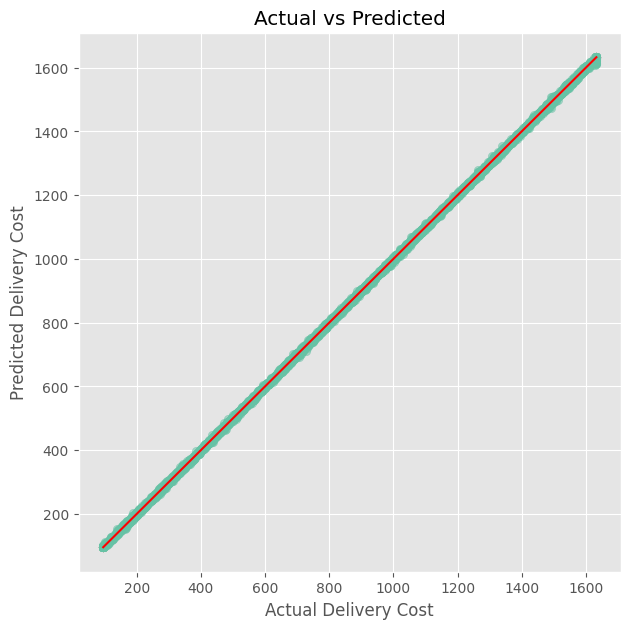

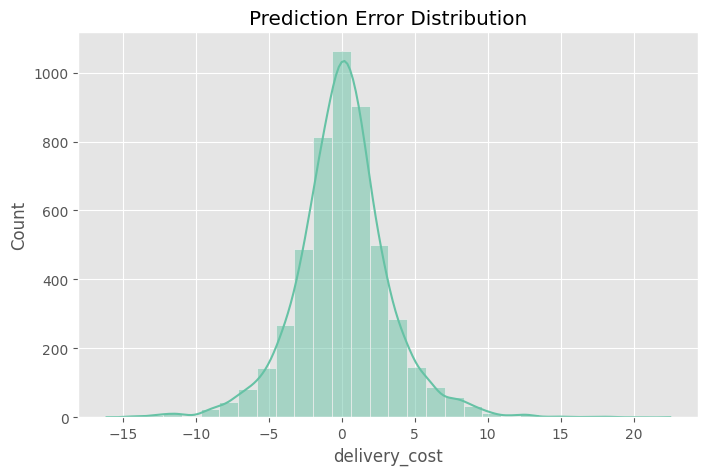


Important Features


,Feature,Importance
6,distance_km,0.982281
7,package_weight_kg,0.009423
3,delivery_mode,0.008174


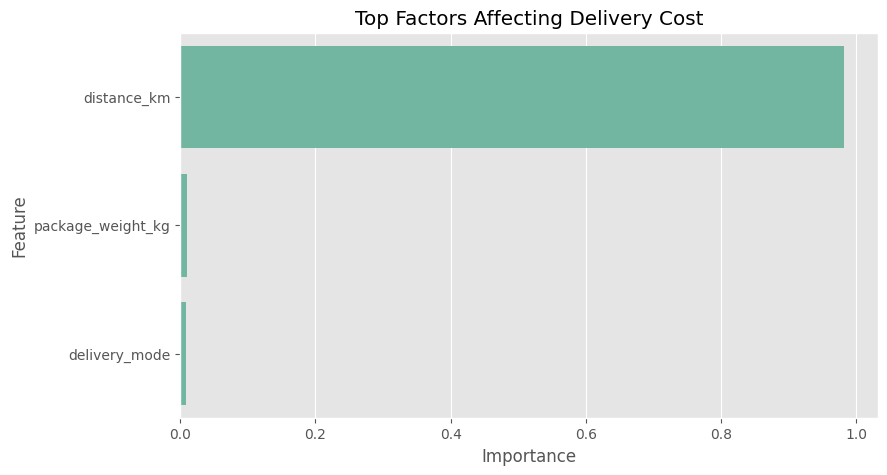


FINAL BUSINESS INSIGHTS
Best Model              : Random Forest
Average Error (MAE)     : ₹2.34
Root Mean Square Error  : ₹3.25
Median Prediction Error : ₹1.69

Top Cost Drivers:
7. distance_km
8. package_weight_kg
4. delivery_mode

Business Recommendations
• Reduce delivery costs in the 'west' region.
• Review 'same day' delivery operations for better efficiency.
• Improve customer satisfaction for 'xpressbees'.
• Optimize long-distance deliveries.
• Allocate vehicles according to package weight.
• Use historical delivery data for cost estimation.

PROJECT CONCLUSION
This project analyzed logistics delivery data using
Exploratory Data Analysis, Feature Engineering, and
Machine Learning techniques.
The analysis identified the major factors influencing
delivery costs and compared multiple regression models.
The generated insights can support better logistics
planning and operational decision-making.

Project Completed Successfully.


In [34]:
# ==========================================================
# MACHINE LEARNING MODEL DEVELOPMENT
# ==========================================================

print("=" * 70)
print("MACHINE LEARNING MODEL DEVELOPMENT")
print("=" * 70)

# ----------------------------------------------------------
# Prepare Data
# ----------------------------------------------------------

X = df_processed.drop("delivery_cost", axis=1)
y = df_processed["delivery_cost"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Scale only numerical features
numerical_cols = [
    "distance_km",
    "package_weight_kg",
    "delivery_rating"
]

numerical_cols = [col for col in numerical_cols if col in X_train.columns]

scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("\nData prepared successfully.")
print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

# ----------------------------------------------------------
# Models
# ----------------------------------------------------------

models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=150,
        max_depth=15,
        random_state=42
    )
}

# ----------------------------------------------------------
# Train Models
# ----------------------------------------------------------

results = []
trained_models = {}

print("\nTraining Models...\n")

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    median_error = np.median(np.abs(y_test - pred))

    trained_models[name] = model

    results.append({
        "Model": name,
        "MAE": round(mae,2),
        "RMSE": round(rmse,2),
        "Median Error": round(median_error,2)
    })

    print(f"✔ {name} completed")

# ----------------------------------------------------------
# Comparison Table
# ----------------------------------------------------------

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="MAE"
).reset_index(drop=True)

print("\nModel Performance")

display(results_df)

# ----------------------------------------------------------
# Comparison Plot
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="MAE"
)

plt.title("Model Comparison")
plt.ylabel("Mean Absolute Error (₹)")
plt.show()

# ----------------------------------------------------------
# Best Model
# ----------------------------------------------------------

best_model_name = results_df.loc[0,"Model"]

best_model = trained_models[best_model_name]

print(f"\nBest Model : {best_model_name}")

# ----------------------------------------------------------
# Actual vs Predicted
# ----------------------------------------------------------

prediction = best_model.predict(X_test)

plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    prediction,
    alpha=0.5
)

plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    color="red"
)

plt.xlabel("Actual Delivery Cost")
plt.ylabel("Predicted Delivery Cost")
plt.title("Actual vs Predicted")

plt.show()

# ----------------------------------------------------------
# Residual Distribution
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

sns.histplot(
    y_test-prediction,
    bins=30,
    kde=True
)

plt.title("Prediction Error Distribution")

plt.show()

# ----------------------------------------------------------
# Feature Importance
# ----------------------------------------------------------

rf = trained_models["Random Forest"]

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance = importance[
    importance["Importance"]>0.001
]

print("\nImportant Features")

display(importance)

plt.figure(figsize=(9,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Top Factors Affecting Delivery Cost")

plt.show()

# ----------------------------------------------------------
# Business Insights
# ----------------------------------------------------------

print("\n"+"="*70)
print("FINAL BUSINESS INSIGHTS")
print("="*70)

best = results_df.iloc[0]

print(f"Best Model              : {best['Model']}")
print(f"Average Error (MAE)     : ₹{best['MAE']}")
print(f"Root Mean Square Error  : ₹{best['RMSE']}")
print(f"Median Prediction Error : ₹{best['Median Error']}")

print("\nTop Cost Drivers:")

for i,row in importance.head(5).iterrows():
    print(f"{i+1}. {row['Feature']}")

# ----------------------------------------------------------
# Dataset-based Recommendations
# ----------------------------------------------------------

highest_region = df.groupby("region")["delivery_cost"].mean().idxmax()
highest_mode = df.groupby("delivery_mode")["delivery_cost"].mean().idxmax()
lowest_partner = df.groupby("delivery_partner")["delivery_rating"].mean().idxmin()

print("\nBusiness Recommendations")

print(f"• Reduce delivery costs in the '{highest_region}' region.")
print(f"• Review '{highest_mode}' delivery operations for better efficiency.")
print(f"• Improve customer satisfaction for '{lowest_partner}'.")
print("• Optimize long-distance deliveries.")
print("• Allocate vehicles according to package weight.")
print("• Use historical delivery data for cost estimation.")

# ----------------------------------------------------------
# Project Conclusion
# ----------------------------------------------------------

print("\n"+"="*70)
print("PROJECT CONCLUSION")
print("="*70)

print("This project analyzed logistics delivery data using")
print("Exploratory Data Analysis, Feature Engineering, and")
print("Machine Learning techniques.")
print("The analysis identified the major factors influencing")
print("delivery costs and compared multiple regression models.")
print("The generated insights can support better logistics")
print("planning and operational decision-making.")

print("\nProject Completed Successfully.")